# Clean Label Attack: Feature Poisoning Without Label Changes

A clean label attack perturbs the features of a few training points while keeping their original labels
unchanged, forcing the retrained decision boundary to shift and misclassify a separate target point.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, classification_report

SEED = 1337
np.random.seed(SEED)

# --- color palette ---
bg_dark      = "#141d2b"
grid_grey    = "#a4b1cd"
text_white   = "#ffffff"
pink_primary = "#ff2e88"  # titles / accents
pink_class0  = "#c724b1"  # Class 0 data points
pink_class1  = "#ffb3c6"  # Class 1 data points
pink_class2  = "#8e2984"  # Class 2 data points
pink_alert   = "#ff1053"  # perturbed-point highlight

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({
    "figure.facecolor": bg_dark,
    "axes.facecolor": bg_dark,
    "axes.edgecolor": grid_grey,
    "axes.labelcolor": text_white,
    "text.color": text_white,
    "xtick.color": grid_grey,
    "ytick.color": grid_grey,
    "grid.color": grid_grey,
    "grid.alpha": 0.1,
    "legend.facecolor": bg_dark,
    "legend.edgecolor": grid_grey,
    "legend.frameon": True,
    "legend.framealpha": 1.0,
    "legend.labelcolor": text_white,
})

class_colors = [pink_class0, pink_class1, pink_class2]
print("Setup complete.")

Setup complete.


## 1. Synthetic 3-class dataset

`make_blobs` generates three Gaussian clusters standardized with `StandardScaler`, standing in for a
3-class quality-control scenario (e.g. Major Defect / Acceptable / Minor Defect).

In [2]:
n_samples = 1500
centers = [(0, 6), (4, 3), (8, 6)]
X, y = make_blobs(n_samples=n_samples, centers=centers, n_features=2, cluster_std=1.15, random_state=SEED)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=SEED, stratify=y,
)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples | Classes: {np.unique(y)}")

Train: 1050 samples | Test: 450 samples | Classes: [0 1 2]


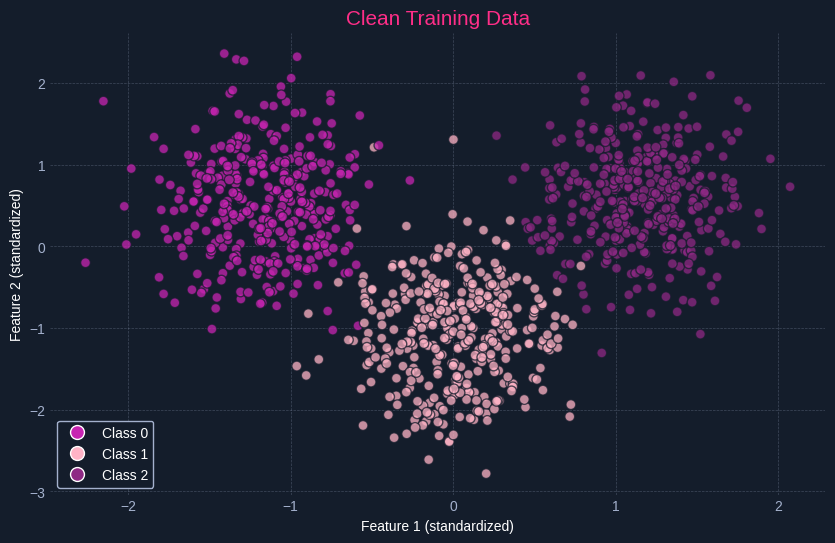

In [3]:
def plot_data(X, y, title, highlights=None):
    """highlights: list of (index, marker, edge_color, label) tuples."""
    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.colors.ListedColormap(class_colors),
                edgecolors=bg_dark, s=50, alpha=0.75)

    handles = [plt.Line2D([0], [0], marker="o", color="w", label=f"Class {i}",
                          markersize=10, markerfacecolor=class_colors[i], linestyle="None")
               for i in range(len(class_colors))]

    if highlights:
        for idx, marker, edge, label in highlights:
            face = class_colors[int(y[idx])]
            plt.scatter(X[idx, 0], X[idx, 1], facecolors=face, edgecolors=edge,
                        marker=marker, s=220, linewidths=2, zorder=5)
            handles.append(plt.Line2D([0], [0], marker=marker, color="w", label=label,
                                       markerfacecolor=face, markeredgecolor=edge,
                                       markersize=12, linestyle="None", markeredgewidth=2))

    plt.title(title, fontsize=15, color=pink_primary)
    plt.xlabel("Feature 1 (standardized)"); plt.ylabel("Feature 2 (standardized)")
    plt.legend(handles=handles)
    plt.grid(True, color=grid_grey, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.show()

plot_data(X_train, y_train, "Clean Training Data")

## 2. Baseline model

`OneVsRestClassifier(LogisticRegression)` trains one binary classifier per class; a point's predicted
class is whichever binary model scores it highest.

Baseline accuracy on clean test set: 0.9600


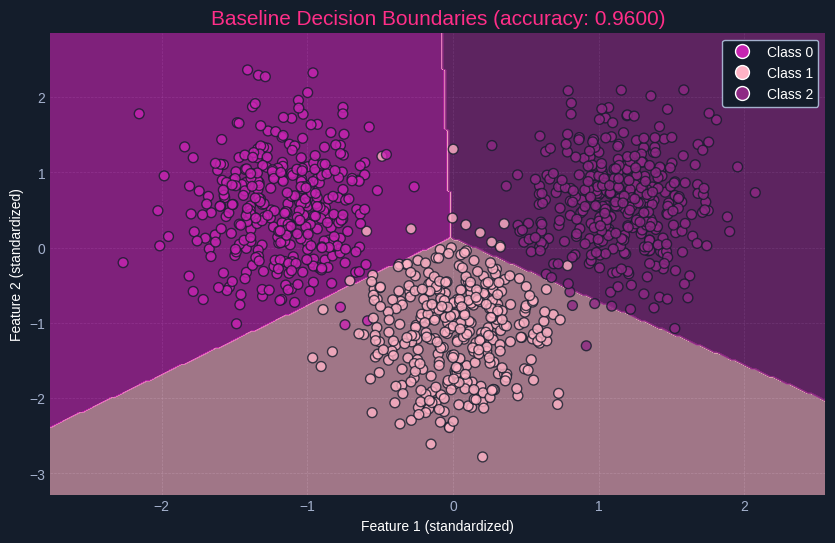

In [6]:
def plot_decision_boundary(X, y, model, title, highlights=None):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    light_colors = [c + "60" for c in class_colors]
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.colors.ListedColormap(light_colors), alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.colors.ListedColormap(class_colors),
                edgecolors=bg_dark, s=50, alpha=0.8)

    handles = [plt.Line2D([0], [0], marker="o", color="w", label=f"Class {i}",
                          markersize=10, markerfacecolor=class_colors[i], linestyle="None")
               for i in range(len(class_colors))]

    if highlights:
        for idx, marker, edge, label in highlights:
            face = class_colors[int(y[idx])]
            plt.scatter(X[idx, 0], X[idx, 1], facecolors=face, edgecolors=edge,
                        marker=marker, s=220, linewidths=2, zorder=5)
            handles.append(plt.Line2D([0], [0], marker=marker, color="w", label=label,
                                       markerfacecolor=face, markeredgecolor=edge,
                                       markersize=12, linestyle="None", markeredgewidth=2))

    plt.title(title, fontsize=15, color=pink_primary)
    plt.xlabel("Feature 1 (standardized)"); plt.ylabel("Feature 2 (standardized)")
    plt.legend(handles=handles)
    plt.grid(True, color=grid_grey, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.xlim(xx.min(), xx.max()); plt.ylim(yy.min(), yy.max())
    plt.show()

baseline_model = OneVsRestClassifier(LogisticRegression(random_state=SEED, C=1.0, solver="liblinear"))
baseline_model.fit(X_train, y_train)
baseline_accuracy = accuracy_score(y_test, baseline_model.predict(X_test))
print(f"Baseline accuracy on clean test set: {baseline_accuracy:.4f}")

plot_decision_boundary(X_train, y_train, baseline_model,
                        f"Baseline Decision Boundaries (accuracy: {baseline_accuracy:.4f})")

## 3. Selecting a target point

Among genuine Class 1 points correctly classified by the baseline, the one closest to the Class 0/Class 1
boundary is selected as the attack target, using the score-difference function `f01(x) = (w0-w1).x + (b0-b1)`.

Target point index: 373
Target true class: 1 | f01 score: -0.0493


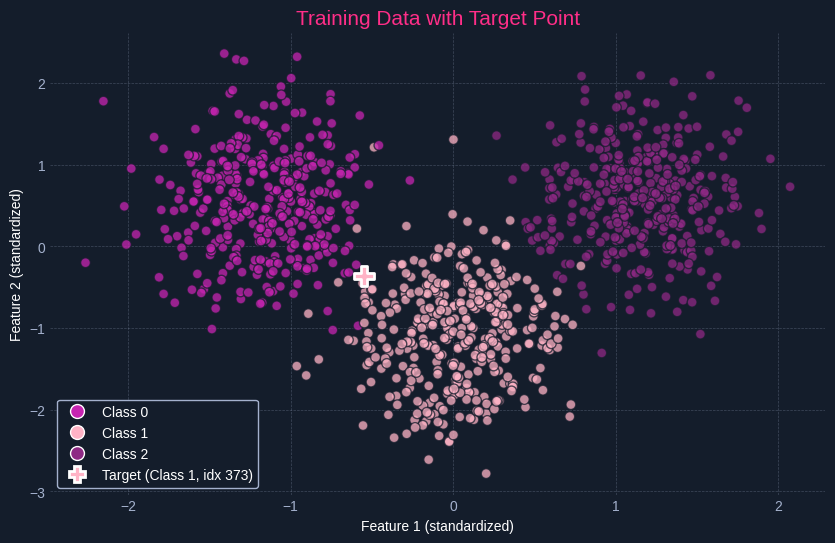

In [7]:
w0, b0 = baseline_model.estimators_[0].coef_[0], baseline_model.estimators_[0].intercept_[0]
w1, b1 = baseline_model.estimators_[1].coef_[0], baseline_model.estimators_[1].intercept_[0]
w_diff_01 = w0 - w1
b_diff_01 = b0 - b1

class1_indices = np.where(y_train == 1)[0]
f01_scores = X_train[class1_indices] @ w_diff_01 + b_diff_01
correct_mask = f01_scores < 0
target_rel_idx = np.where(correct_mask)[0][np.argmax(f01_scores[correct_mask])]
target_idx = class1_indices[target_rel_idx]

print(f"Target point index: {target_idx}")
print(f"Target true class: {y_train[target_idx]} | f01 score: {f01_scores[correct_mask].max():.4f}")

plot_data(X_train, y_train, "Training Data with Target Point",
          highlights=[(target_idx, "P", text_white, f"Target (Class {y_train[target_idx]}, idx {target_idx})")])

## 4. The attack

The nearest same-boundary neighbors of a different class are pushed toward the target's class along the
boundary's normal vector, by a fixed distance, while their original label is kept unchanged.

Perturbed 5 Class 0 points: [ 761   82 1035  919  491]


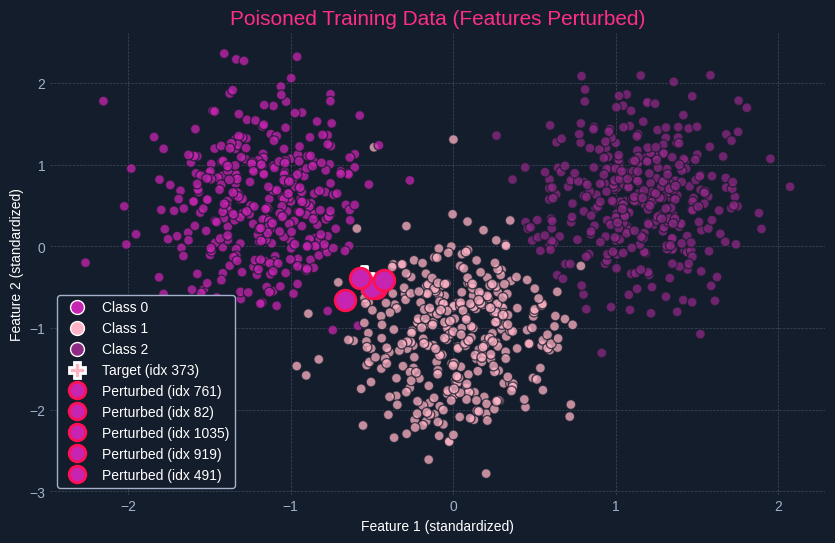

In [8]:
def clean_label_attack(X_train, y_train, target_idx, target_class, perturb_class,
                        w_by_class, b_by_class, n_neighbors, epsilon_cross):
    w_target, w_perturb = w_by_class[target_class], w_by_class[perturb_class]

    X_target_point = X_train[target_idx]
    perturb_indices = np.where(y_train == perturb_class)[0]
    X_perturb = X_train[perturb_indices]

    nn = NearestNeighbors(n_neighbors=n_neighbors).fit(X_perturb)
    _, rel_idx = nn.kneighbors(X_target_point.reshape(1, -1))
    neighbor_indices = perturb_indices[rel_idx.flatten()]

    push_direction = w_target - w_perturb
    unit_push = push_direction / np.linalg.norm(push_direction)
    perturbation = epsilon_cross * unit_push

    X_poisoned = X_train.copy()
    y_poisoned = y_train.copy()
    for idx in neighbor_indices:
        X_poisoned[idx] = X_poisoned[idx] + perturbation

    return X_poisoned, y_poisoned, neighbor_indices


w_by_class = {0: w0, 1: w1}
b_by_class = {0: b0, 1: b1}

X_train_poisoned, y_train_poisoned, perturbed_indices = clean_label_attack(
    X_train, y_train, target_idx, target_class=1, perturb_class=0,
    w_by_class=w_by_class, b_by_class=b_by_class, n_neighbors=5, epsilon_cross=0.25,
)

print(f"Perturbed {len(perturbed_indices)} Class 0 points: {perturbed_indices}")

plot_data(
    X_train_poisoned, y_train_poisoned, "Poisoned Training Data (Features Perturbed)",
    highlights=[(target_idx, "P", text_white, f"Target (idx {target_idx})")]
    + [(idx, "o", pink_alert, f"Perturbed (idx {idx})") for idx in perturbed_indices],
)

## 5. Evaluation

The poisoned model is retrained on the perturbed features and evaluated on the target point and on the
unmodified clean test set.

Target true class: 1 | baseline prediction: 1 | poisoned prediction: 0
Baseline accuracy: 0.9600
Poisoned accuracy: 0.9578
              precision    recall  f1-score   support

     Class 0       0.98      0.99      0.98       150
     Class 1       0.94      0.93      0.94       150
     Class 2       0.95      0.95      0.95       150

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



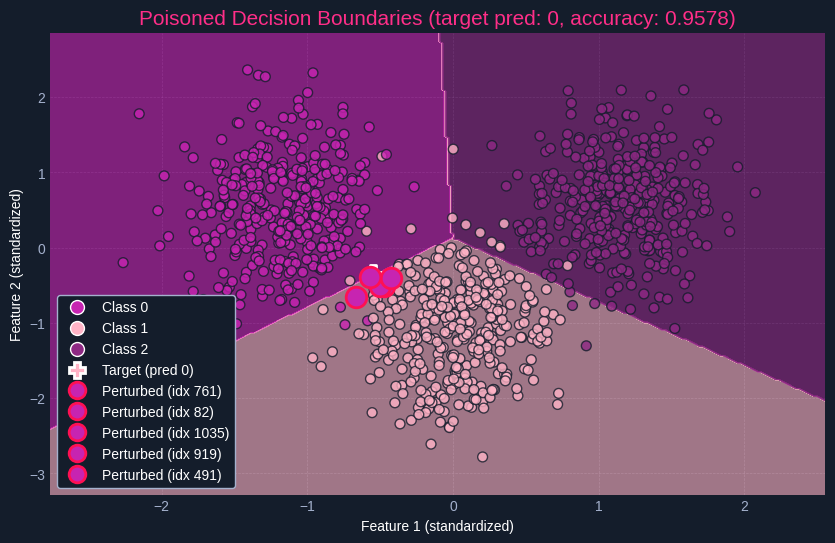

In [10]:
poisoned_model = OneVsRestClassifier(LogisticRegression(random_state=SEED, C=1.0, solver="liblinear"))
poisoned_model.fit(X_train_poisoned, y_train_poisoned)

target_pred = poisoned_model.predict(X_train[target_idx].reshape(1, -1))[0]
print(f"Target true class: {y_train[target_idx]} | baseline prediction: 1 | poisoned prediction: {target_pred}")

poisoned_accuracy = accuracy_score(y_test, poisoned_model.predict(X_test))
print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Poisoned accuracy: {poisoned_accuracy:.4f}")

print(classification_report(y_test, poisoned_model.predict(X_test),
                             target_names=[f"Class {i}" for i in range(3)]))

plot_decision_boundary(
    X_train_poisoned, y_train_poisoned, poisoned_model,
    f"Poisoned Decision Boundaries (target pred: {target_pred}, accuracy: {poisoned_accuracy:.4f})",
    highlights=[(target_idx, "P", text_white, f"Target (pred {target_pred})")]
    + [(idx, "o", pink_alert, f"Perturbed (idx {idx})") for idx in perturbed_indices],
)

## Results

The target point (index 373, true Class 1) is predicted Class 0 after retraining on the poisoned data, while
overall test accuracy changes from 0.9600 to 0.9578.